In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.graph_color import color_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian
from copy import copy
from koala.lattice import INVALID
from koala import example_graphs as eg
from dimer_models.koala_plantri import plantri_to_koala, plantri_generator, read_plantri
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)
from math import ceil
from tqdm import tqdm

import matplotlib as mpl
from collections import Counter

from dimer_models.kasteleyn import find_kasteleyn_number

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


mpl.rcParams.update(
    {
        "font.size": 11,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)

import pickle

In [ ]:
results = []
with open("strip_density.pkl", "rb") as f:
    while True:
        try:
            results.append(pickle.load(f))
        except EOFError:
            break

spacings = [1, 2, 3, 4, 5, 6, 10, 12, 15, 20, 30]

In [19]:
norms = []
for j, res in enumerate(results):
    norm = res["probs"] - 1 / 3
    norm = np.max(np.abs(norm))
    norms.append(norm)
global_norm = np.max(norms)

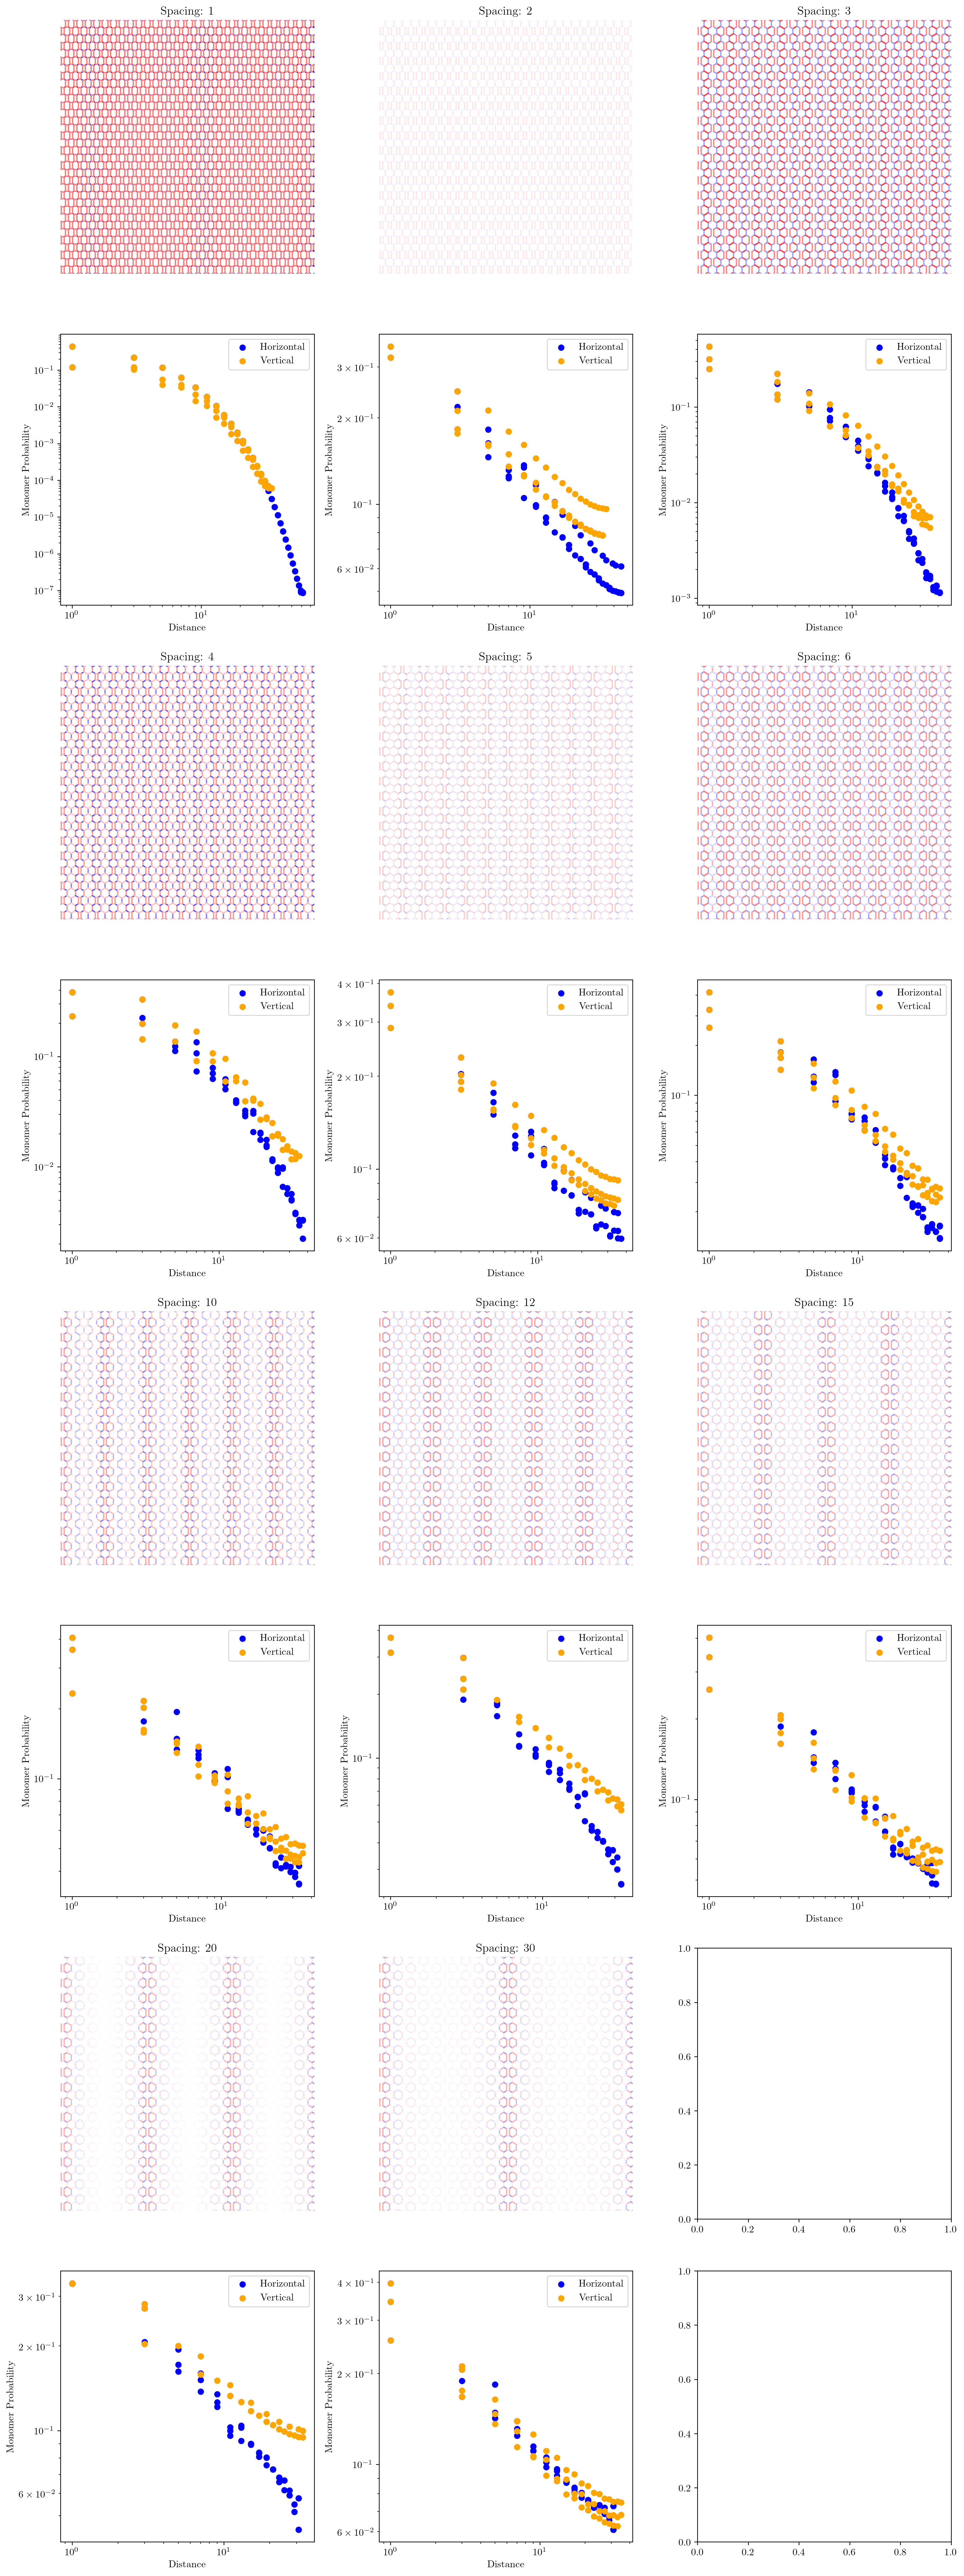

In [ ]:
n_results = len(results)
fig, ax = plt.subplots(
    8, ceil(n_results / 4), figsize=5 * np.array([ceil(n_results / 4), 8]), dpi=200
)
plot_axes = ax[::2].flatten()
graph_axes = ax[1::2].flatten()

for j, res in enumerate(results):

    plot_axes[j].set_title(f"Spacing: {spacings[j]}")
    # lattice = gu.com_relaxation(res["lattice"])
    lattice = res["lattice"]
    plot_axes[j].set_aspect("equal")
    # plot the graph
    probs_normalised = res["probs"] - 1 / 3
    probs_normalised = 0.5 * probs_normalised / global_norm
    edge_labels = np.arange(lattice.n_edges)
    cmap = plt.get_cmap("bwr")
    color_scheme = cmap(probs_normalised + 0.5)  # Shift to center around 0
    pl.plot_edges(
        lattice,
        ax=plot_axes[j],
        labels=edge_labels,
        color_scheme=color_scheme,
    )
    plot_axes[j].set_axis_off()

    # plot the monomer probabilities
    monomer_prob_h = res["monomer_probs_hor"]
    monomer_prob_v = res["monomer_probs_vert"]
    distances_h = res["distances_horizontal"]
    distances_v = res["distances_vertical"]

    graph_axes[j].scatter(distances_h, monomer_prob_h, label="Horizontal", color="Blue")
    graph_axes[j].scatter(distances_v, monomer_prob_v, label="Vertical", color="orange")

    graph_axes[j].set_xlabel("Distance")
    graph_axes[j].set_ylabel("Monomer Probability")
    graph_axes[j].set_yscale("log")
    graph_axes[j].set_xscale("log")
    graph_axes[j].legend()

plt.tight_layout()
plt.savefig("strip_density_results_loglog.png", dpi=300, bbox_inches="tight")